# Feed-Forward Neural Networks
This jupyter notebook will try to classify two randomly generated data sets. Each of these two data sets are created by 2000 points which will be seperated to: 70% Train data, 10% Validation data and 20% Test data. I will try to classify spirals and crescents shaped data using both perceptron and multi-layer perceptron a nd give a brief summary of what happened and why?

## Preparation

### Installation

In [26]:
!python -m pip install numpy matplotlib torch scikit-learn tqdm torchsummary

### Imports

In [27]:
from data_gen import Q2Data, make_q2_crescents, make_q2_spirals
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchsummary import summary
from torch.utils.data import TensorDataset, DataLoader
import random
from itertools import product
from tqdm import tqdm

### Data

In [3]:
p_data = {
    "crescents": make_q2_crescents(student_run_seed=1013),
    "spirals": make_q2_spirals(student_run_seed=1013)
}

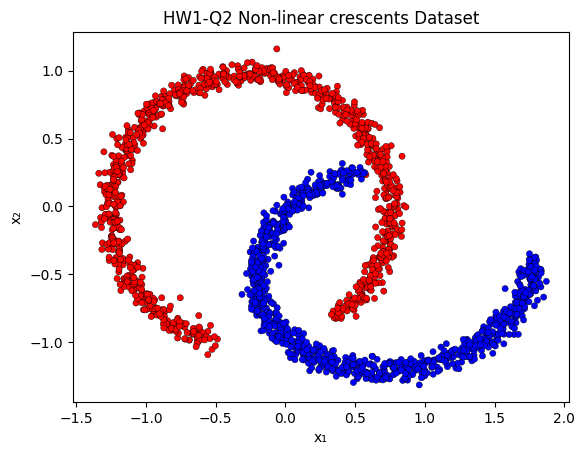

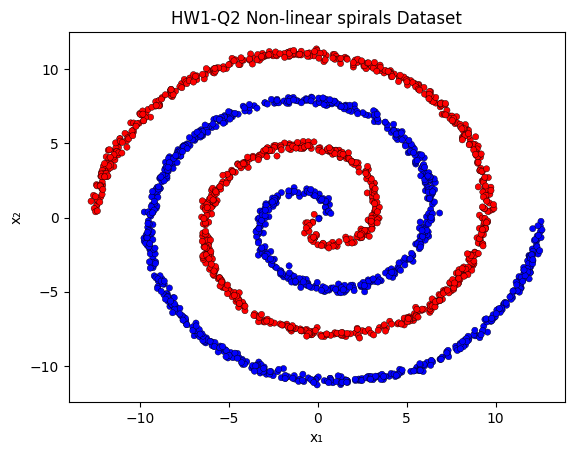

In [4]:
for dset in p_data:
    X = torch.cat([p_data[dset].X_train,p_data[dset].X_val,p_data[dset].X_test])
    y = torch.cat([p_data[dset].y_train,p_data[dset].y_val,p_data[dset].y_test])
    plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr", s=20, edgecolor="k", linewidth=0.3)
    plt.title(f"HW1-Q2 Non-linear {dset} Dataset")
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.show()

> Setting a start seed for initialization

In [5]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

## Visualization

1. Confusion matrix is one of the best tools to visulize classification data. It represent the model's sensitivity, specificity, precision and recall without confusing the reader by numbers:
- The following code will plot confusion matrix by receiving a dataloader and the model we want to test.

In [6]:
def plot_confusion_matrix(model, loader, d_part_name, d_name, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs)
            preds = (outputs > threshold).float()  # convert to 0/1
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_preds = torch.tensor(all_preds).view(-1).numpy()
    all_labels = torch.tensor(all_labels).view(-1).numpy()
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix for {d_part_name} of {d_name}")
    plt.show()

2. Seeing what happens to data and how it is classified is one of the most important parts when our data can be easly shown in 1, 2 or even 3 dimentions, therfore I provided a function to do this task:
- For plotting the data that is seprated by a linear/non-linear model, what we have is a decision area(it also covers decision boundary). When we call this methode This function first switches the model to evaluation mode using model.eval() so that layers like dropout or batch normalization behave consistently during visualization.Then it converts the input tensors X and y to NumPy arrays for easier handling with matplotlib. Next, it defines a grid of evenly spaced points covering the area where the data lies, and for each point on that grid, it asks the model to predict the class. Those predictions are reshaped to match the grid and plotted using plt.contourf() to show the decision regions, with the real data points plotted on top.

In [7]:

def plot_decision_boundary(model, X, y, title):
    model.eval()
    X_np = X.detach().numpy()
    y_np = y.detach().numpy()
    x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
    y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5
    xx, yy = np.meshgrid( np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)
    with torch.no_grad():
        preds = model(grid_tensor)
        Z = preds.reshape(xx.shape)
        Z = Z.numpy()
        Z = 1 - Z
    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.9, cmap='RdBu')
    plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='bwr', edgecolors='k', s=40)
    plt.title(str('Voronoi diagram of ' + title))
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

3. Throgh out the trainning process we achive different accuracy and loss function value, in order to analyse what happened and how to fix our model problems I created these two functions to plot the history of accuracy and loss of a model

In [8]:
def plot_accuracy_map(ep_num, t_acc, v_acc, d_name):
    plt.figure(figsize=(7, 5))
    epochs = range(5, ep_num + 5, 5)
    plt.plot(epochs, t_acc, label='Train Accuracy', marker='o')
    plt.plot(epochs, v_acc, label='Validation Accuracy', marker='s')
    plt.title(f'Training vs Validation Accuracy of {d_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

In [9]:
def plot_loss_map(ep_num, t_loss, v_loss, d_name):
    plt.figure(figsize=(7, 5))
    epochs = range(5, ep_num + 5, 5)
    plt.plot(epochs, t_loss, label='Train Loss', marker='o')
    plt.plot(epochs, v_loss, label='Validation Loss', marker='s')
    plt.title(f'Training vs Validation Loss of {d_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

## Models Defenition

Each class has 4 main functions that are implemented by us and not by the super class:<br>
`_init_`: In this function we initialize hyper parameters including optimizer, learning rate, number of layers, loss function, activation function.<br>
`forward`: Forward is one of the **must implement** methods in the creation of this code since it determines how inputs are forwarded through the model.<br>
`train_one_epoch`: After we get the output we need to calculate the loss gained by the input and backpropagate it to layers before, hence we have this function that calculate output and loss, and returns them, also this methode modifies models parameter for train data.<br>
`get_accuracy`: As self-explained this function is it calculate accuracy of mode on a data.<br>

### Single perceptron class

In [10]:
class SinglePerceptron(nn.Module):
    def __init__(self, input_size, criterion, learning_rate, seed=42):
        torch.manual_seed(seed)
        super(SinglePerceptron, self).__init__()
        # ==== MODEL ARCHITECTURE ==== #
        self.linear = nn.Linear(input_size, 1)
        self.sigmoid = nn.Sigmoid()
        # ====== LOSS & OPTIMIZER ====== #
        self.criterion = criterion
        self.optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)

    def forward(self, x):
        return self.sigmoid(self.linear(x))
    
    def train_one_epoch(self, train_loader, val_loader=None):
        # ======== TRAINING ======== #
        self.train()
        train_loss = 0.0
        total_batches = 0
        for inputs, labels in train_loader:
            outputs = self(inputs)
            loss = self.criterion(outputs, labels.view(-1, 1))
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            train_loss += loss.item()
            total_batches += 1
        avg_train_loss = train_loss / total_batches
        # ======== VALIDATION ======== #
        avg_val_loss = None
        if val_loader:
            self.eval()
            val_loss = 0.0
            val_batches = 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    outputs = self(inputs)
                    loss = self.criterion(outputs, labels.view(-1, 1))
                    val_loss += loss.item()
                    val_batches += 1
            avg_val_loss = val_loss / val_batches
        return avg_train_loss, avg_val_loss
    
    def get_accuracy(self, X, y):
        self.eval()
        with torch.no_grad():
            y_pred = self(X)
            predicted_classes = (y_pred > 0.5).float()
        predicted_classes = predicted_classes.view(-1)
        correct = (predicted_classes == y).sum().item()
        return correct / y.size(0)


### Neural network with a single hidden layer class

In [11]:
class SingleHiddenNN(nn.Module):
    def __init__(self, input_size, criterion, hidden_layer_size = 10, learning_rate = 0.001, seed=42):
        torch.manual_seed(seed)
        super(SingleHiddenNN, self).__init__()
        # ==== MODEL ARCHITECTURE ==== #
        self.hidden = nn.Linear(input_size, hidden_layer_size)
        self.relu = nn.ReLU()
        self.output = nn.Linear(hidden_layer_size, 1)
        self.sigmoid = nn.Sigmoid()
        # ====== LOSS & OPTIMIZER ====== #
        self.criterion = criterion
        self.optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.sigmoid(x)
        return x
    
    def train_one_epoch(self, train_loader, val_loader=None):
        # ======== TRAINING ======== #
        self.train()
        train_loss = 0.0
        total_batches = 0
        for inputs, labels in train_loader:
            outputs = self(inputs)
            loss = self.criterion(outputs, labels.view(-1, 1))
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            train_loss += loss.item()
            total_batches += 1
        avg_train_loss = train_loss / total_batches
        # ======== VALIDATION ======== #
        avg_val_loss = None
        if val_loader:
            self.eval()
            val_loss = 0.0
            val_batches = 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    outputs = self(inputs)
                    loss = self.criterion(outputs, labels.view(-1, 1))
                    val_loss += loss.item()
                    val_batches += 1
            avg_val_loss = val_loss / val_batches
        
        return avg_train_loss, avg_val_loss
    
    def get_accuracy(self, X, y):
        self.eval()
        with torch.no_grad():
            y_pred = self(X)
            predicted_classes = (y_pred > 0.5).float()
        predicted_classes = predicted_classes.view(-1)
        correct = (predicted_classes == y).sum().item()
        return correct / y.size(0)

### Multilayer perceptron class

In [21]:
class MLP(nn.Module):
    def __init__(self, input_size, criterion, learning_rate = 0.001, seed=42):
        torch.manual_seed(seed)
        super(MLP, self).__init__()
        # ==== MODEL ARCHITECTURE ==== #
        self.input_layer = nn.Linear(input_size, 8)
        self.relu0 = nn.LeakyReLU()
        self.hidden1 = nn.Linear(8, 8)
        self.relu1 = nn.LeakyReLU()
        self.hidden2 = nn.Linear(8, 4)
        self.relu2 = nn.LeakyReLU()
        self.output = nn.Linear(4, 1) 
        self.Sigmoid = nn.Sigmoid()
        # ====== LOSS & OPTIMIZER ====== #
        self.criterion = criterion
        self.optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)

    def forward(self, x):
        h0 = self.input_layer(x)
        r0 = self.relu0(h0)
        h1 = self.hidden1(r0)
        r1 = self.relu1(h1)
        h2 = self.hidden2(r1)
        r2 = self.relu2(h2)
        out = self.output(r2)
        y = self.Sigmoid(out)
        return y
    
    def train_one_epoch(self, train_loader, val_loader=None):
        # ======== TRAINING ========
        self.train()
        train_loss = 0.0
        total_batches = 0
        for inputs, labels in train_loader:
            outputs = self(inputs)
            loss = self.criterion(outputs, labels.view(-1, 1))
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            train_loss += loss.item()
            total_batches += 1
        avg_train_loss = train_loss / total_batches
        # ======== VALIDATION ========
        avg_val_loss = None
        if val_loader:
            self.eval()
            val_loss = 0.0
            val_batches = 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    outputs = self(inputs)
                    loss = self.criterion(outputs, labels.view(-1, 1))
                    val_loss += loss.item()
                    val_batches += 1
            avg_val_loss = val_loss / val_batches
        
        return avg_train_loss, avg_val_loss
    
    def get_accuracy(self, X, y):
        self.eval()
        with torch.no_grad():
            y_pred = self(X)
            predicted_classes = (y_pred > 0.5).float()
        predicted_classes = predicted_classes.view(-1)
        correct = (predicted_classes == y).sum().item()
        return correct / y.size(0)

## Answers to Homework

### Part A

We trained a perceptron to fit it to two data-sets and the result of this is shown in the table below.
<br>

<h4>🌓 Crescent</h4>

| Metric | Distribution (≈ Normal) | Best Accuracy |
|:-------|:------------------------|:--------------|
| **Train** | ~N(0.7271428571428571, 4.081632653061322e-07) | 0.7278571428571429 |
| **Validation** | ~N(0.735, 0.0) | 0.735 |
| **Test** | ~N(0.772, 6.00000000000001e-06) | 0.77 |


<h4>🌀 Spirals</h4>

| Metric | Distribution (≈ Normal) | Best Accuracy |
|:-------|:------------------------|:--------------|
| **Train** | ~N(0.6115714285714287, 8.979591836734782e-07) | 0.6128571428571429 |
| **Validation** | ~N(0.5745, 8.499999999999883e-06) | 0.58 |
| **Test** | ~N(0.605, 0.0) | 0.605 |


***
Now to compare this data and see how best model worked out we can visualize it's for a better comprehension:<br>
<h4>🌓 Crescent</h4>

![Accuracy vs Epochs](.\Output\Voronoi.diagram.crescents.perceptron.png)


<h4>🌀 Spirals</h4>

![Accuracy vs Epochs](.\Output\Voronoi.diagram.spirals.perceptron.png)


***
As obvious in results perceptron can not classify problems that their data is not linearly separable. This was also mentioned in Neural Networks & Learning Machines 2008, chapter 1, page 50, Rosenblatt’s perceptron. The referenced paragraph says `"For the perceptron to function properly,the two classes c1 and c2 must be linearly separable.This,in turn,means that the patterns to be classified must be sufficiently separated from each other to ensure that the decision surface consists of a hyperplane..."`, this is because perceptron can only create a linear combination of it's input and sigmoid in short just map them to a label in this case. In other words when there is no line that can separate two data we can not expect perceptron to do this.

100%|██████████| 100/100 [00:03<00:00, 32.20it/s]

Train accuracy has the distribution: ~N(0.7271428571428571, 4.081632653061322e-07)
Validation accuracy has the distribution: ~N(0.735, 0.0)
Test accuracy has the distribution: ~N(0.772, 6.00000000000001e-06)
crescents dataset perceptron best results ==>
	Train Accuracy: 0.7278571428571429
	Validation Accuracy: 0.735
	Test Accuracy: 0.77



C:\Users\Diego\AppData\Local\Temp\ipykernel_10856\458907338.py:11: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  all_preds = torch.tensor(all_preds).view(-1).numpy()


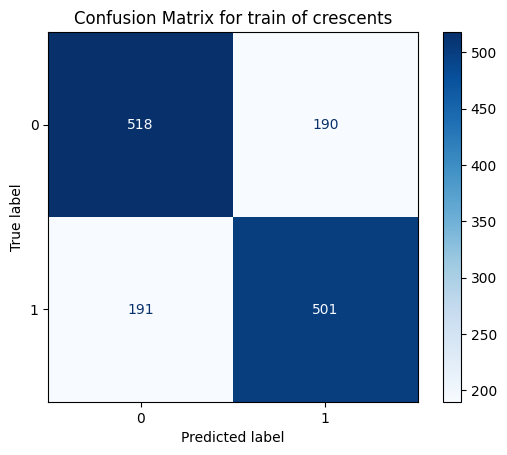

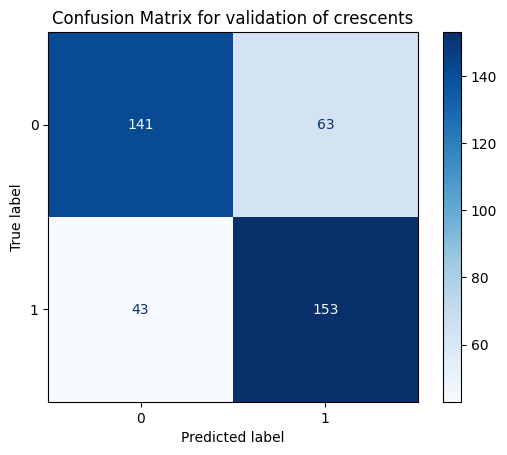

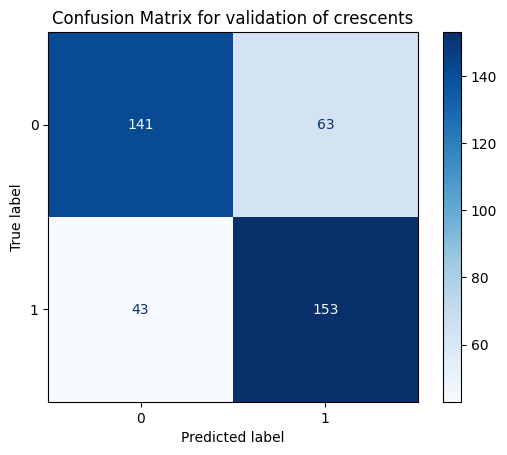

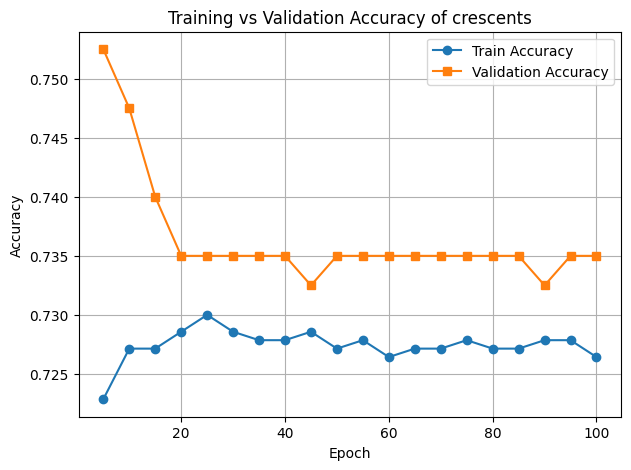

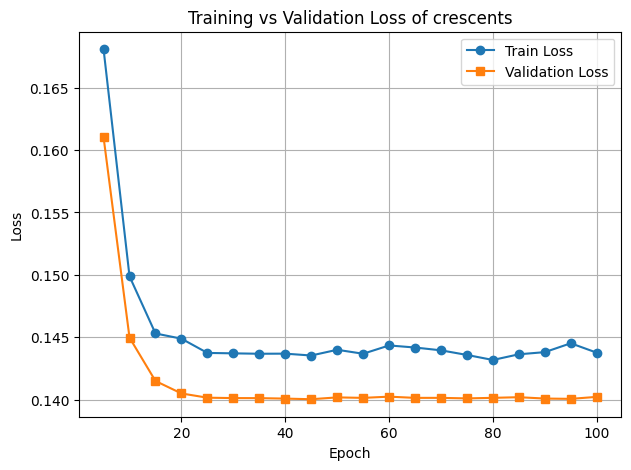

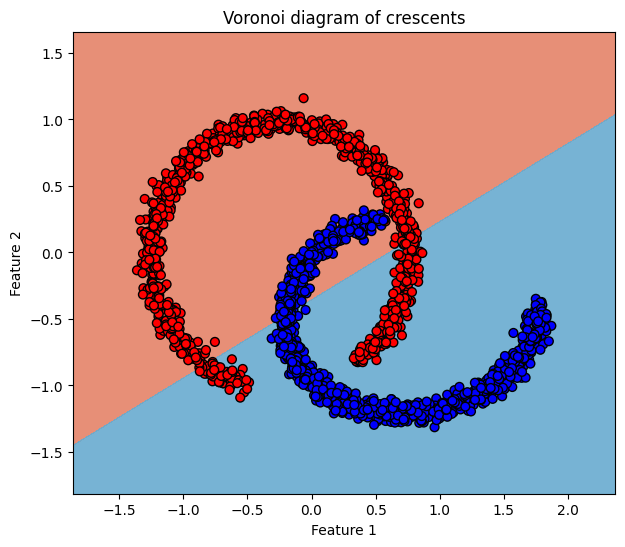

100%|██████████| 100/100 [00:03<00:00, 30.44it/s]


Train accuracy has the distribution: ~N(0.6115714285714287, 8.979591836734782e-07)
Validation accuracy has the distribution: ~N(0.5745, 8.499999999999883e-06)
Test accuracy has the distribution: ~N(0.605, 0.0)
spirals dataset perceptron best results ==>
	Train Accuracy: 0.6128571428571429
	Validation Accuracy: 0.58
	Test Accuracy: 0.605


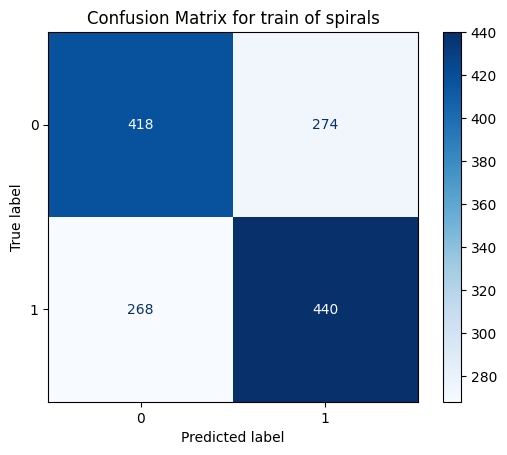

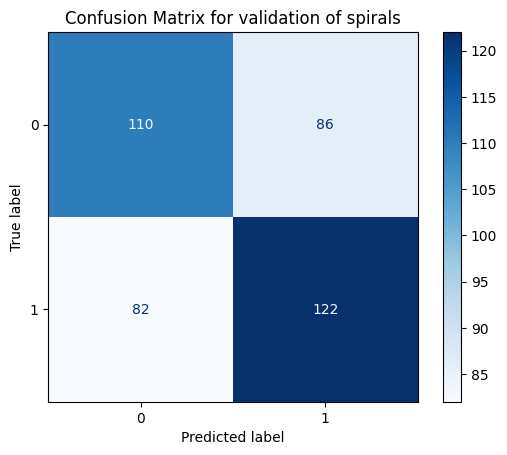

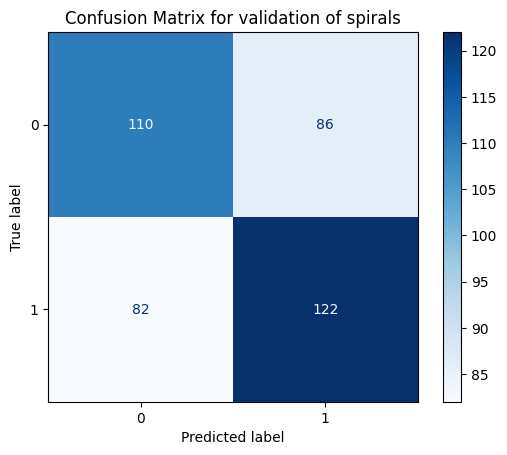

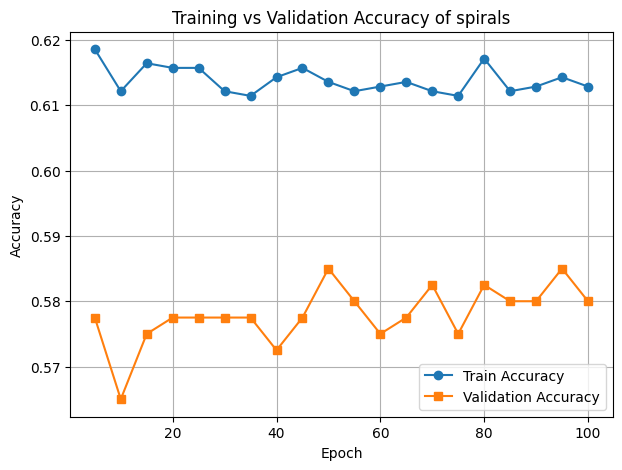

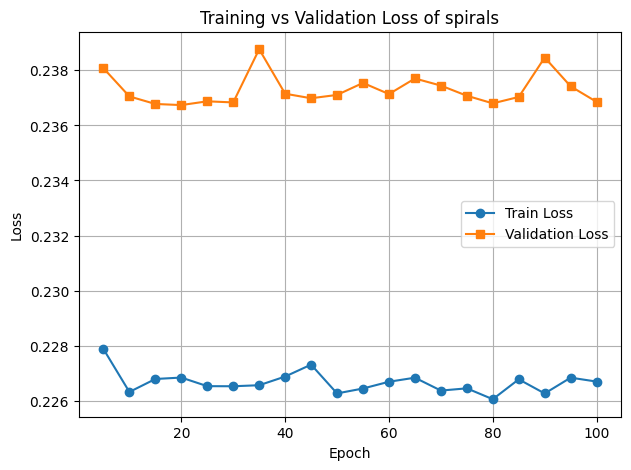

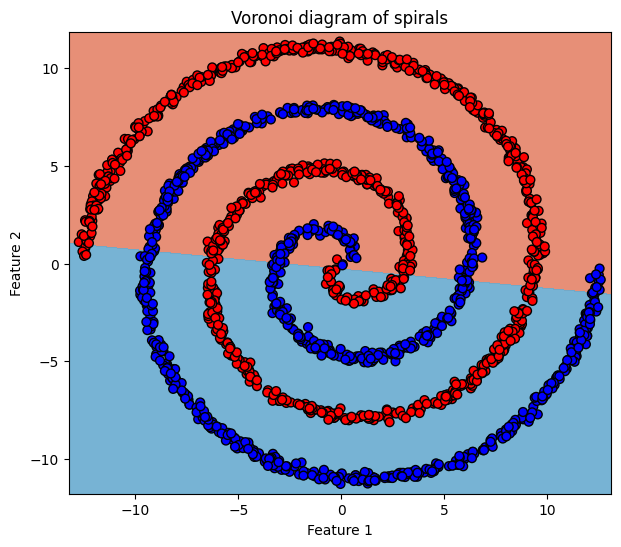

In [14]:
for dset in p_data:
    train_loader = DataLoader(TensorDataset(p_data[dset].X_train, p_data[dset].y_train.float()), batch_size=16, shuffle=True)
    validation_loader = DataLoader(TensorDataset(p_data[dset].X_val, p_data[dset].y_val.float()), batch_size=16)
    test_loader = DataLoader(TensorDataset(p_data[dset].X_test, p_data[dset].y_test.float()), batch_size=16)
    train_acc = []
    val_acc = []
    test_acc = []
    best_model = {
        'train': {
            'acc': [],
            'loss': []
        },
        'val': {
            'acc': [],
            'loss': []
        },
        'model': None
    }
    num_epochs = 100
    lr = 0.002
    for i in range(5):
        train_accuracy = []
        train_loss = []
        val_accuracy = []
        val_loss = []
        model = SinglePerceptron(2, nn.MSELoss(), lr, 40 + i )
        for epoch in tqdm(range(num_epochs)):
            t_loss, v_loss = model.train_one_epoch(train_loader, validation_loader)
            if (epoch + 1) % 5 == 0:
                train_accuracy.append(model.get_accuracy(p_data[dset].X_train, p_data[dset].y_train))
                val_accuracy.append(model.get_accuracy(p_data[dset].X_val, p_data[dset].y_val))
                train_loss.append(t_loss)
                val_loss.append(v_loss)
        train_acc.append(model.get_accuracy(p_data[dset].X_train, p_data[dset].y_train))
        val_acc.append(model.get_accuracy(p_data[dset].X_val, p_data[dset].y_val))
        test_acc.append(model.get_accuracy(p_data[dset].X_test, p_data[dset].y_test))
        if not best_model['val']['acc'] or val_acc[-1] > best_model['val']['acc'][-1]:
            best_model['train']['acc'] = train_accuracy
            best_model['train']['loss'] = train_loss
            best_model['val']['acc'] = val_accuracy
            best_model['val']['loss'] = val_loss
            best_model['model'] = model
    X = torch.cat([p_data[dset].X_train,p_data[dset].X_val,p_data[dset].X_test])
    y = torch.cat([p_data[dset].y_train,p_data[dset].y_val,p_data[dset].y_test])
    
    train_acc = np.array(train_acc)
    print(f'Train accuracy has the distribution: ~N({np.mean(train_acc)}, {np.var(train_acc)})')
    val_acc = np.array(val_acc)
    print(f'Validation accuracy has the distribution: ~N({np.mean(val_acc)}, {np.var(val_acc)})')
    test_acc = np.array(test_acc)
    print(f'Test accuracy has the distribution: ~N({np.mean(test_acc)}, {np.var(test_acc)})')

    print(f'{dset} dataset perceptron best results ==>')
    print('\tTrain Accuracy:', best_model['train']['acc'][-1])
    print('\tValidation Accuracy:', best_model['val']['acc'][-1])
    print('\tTest Accuracy:', best_model['model'].get_accuracy(p_data[dset].X_test, p_data[dset].y_test))

    plot_confusion_matrix(best_model['model'], train_loader, 'train', dset)
    plot_confusion_matrix(best_model['model'], validation_loader, 'validation', dset)
    plot_confusion_matrix(best_model['model'], validation_loader, 'validation', dset)
    plot_accuracy_map(num_epochs, train_accuracy, val_accuracy, dset)
    plot_loss_map(num_epochs, train_loss, val_loss, dset)
    plot_decision_boundary(best_model['model'], X, y, dset)
    

### Part B

After we trained a perceptron we saw that it failed to classify both sets, hence we add a hidden layer to the architecture and we get a model that forwards input to out put like this: input --> 10 * p --> 1 * p --> output
now we want to evaluate this model and we have the following summary of evaluation we had on the data:
<br>

<h4>🌓 Crescent</h4>

| Metric | Distribution (≈ Normal) | Best Accuracy |
|:-------|:------------------------|:--------------|
| **Train** | ~N(0.9767142857142858, 0.0019158367346938797) | 1.0 |
| **Validation** | ~N(0.975, 0.0013600000000000023) | 0.9975 |
| **Test** | ~N(0.9810000000000001, 0.001103999999999999) | 1.0 |


<h4>🌀 Spirals</h4>

| Metric | Distribution (≈ Normal) | Best Accuracy |
|:-------|:------------------------|:--------------|
| **Train** | ~N(0.5930000000000001, 0.0016706938775510182) | 0.6307142857142857 |
| **Validation** | ~N(0.558, 0.0014935000000000005) | 0.5925 |
| **Test** | ~N(0.588, 0.0006859999999999993) | 0.585 |


***
Now to compare this data and see how best model worked out we can visualize it's for a better comprehension. We also added how the train process went on by plotting the loss and accuracy of model for train and validation data:<br>
<h4>🌓 Crescent</h4>

![Accuracy Diagram](.\Output\Accuracy.diagram.crescents.single.layer.png)
![Loss Diagram](.\Output\Loss.diagram.crescents.single.layer.png)
![Voronoi Diagram](.\Output\Voronoi.diagram.crescents.single.layer.png)


<h4>🌀 Spirals</h4>

![Accuracy Diagram](.\Output\Accuracy.diagram.spirals.single.layer.png)
![Loss Diagram](.\Output\Loss.diagram.spirals.single.layer.png)
![Voronoi Diagram](.\Output\Voronoi.diagram.spirals.single.layer.png)


You can see that represented Voronoi diagram of both data sets single hidden layer helped the model to advance from being a linear model which we saw in perceptron diagram to a more complex classifier that can now separate convex patterns of data.

***
Adding a single hidden layer to a perceptron transforms it from a linear classifier into a nonlinear model, allowing it to learn complex decision boundaries that cannot be represented by a single hyperplane. Technically, the hidden layer introduces nonlinear activation functions (such as ReLU, sigmoid, or tanh), enabling the model to compute nonlinear combinations of input features and thus capture higher-order correlations in the data. This increases its representational capacity, allowing it to approximate any continuous function on compact subsets of ℝⁿ (as guaranteed by the universal approximation theorem). Furthermore, the presence of the hidden layer improves generalization by allowing the network to extract intermediate feature representations that separate classes in a transformed feature space, rather than memorizing raw input-output mappings as in a single-layer perceptron.

100%|██████████| 200/200 [00:11<00:00, 17.85it/s]

Train accuracy has the distribution: ~N(0.9767142857142858, 0.0019158367346938797)
Validation accuracy has the distribution: ~N(0.975, 0.0013600000000000023)
Test accuracy has the distribution: ~N(0.9810000000000001, 0.001103999999999999)
crescents dataset perceptron best results ==>
	Train Accuracy: 1.0
	Validation Accuracy: 0.9975
	Test Accuracy: 1.0


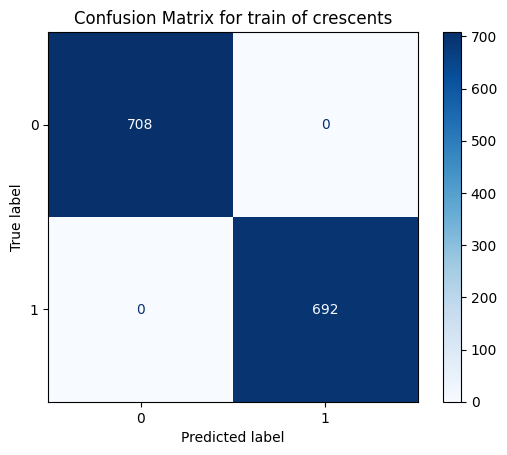

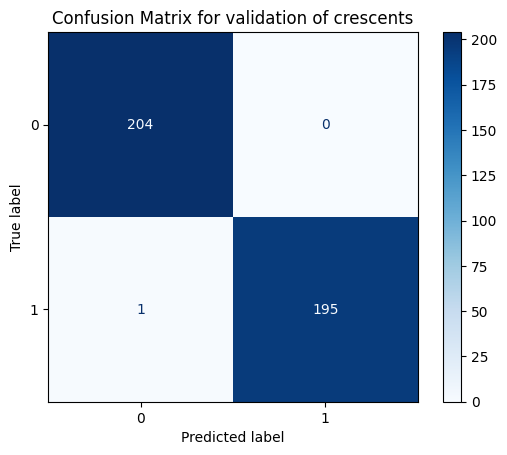

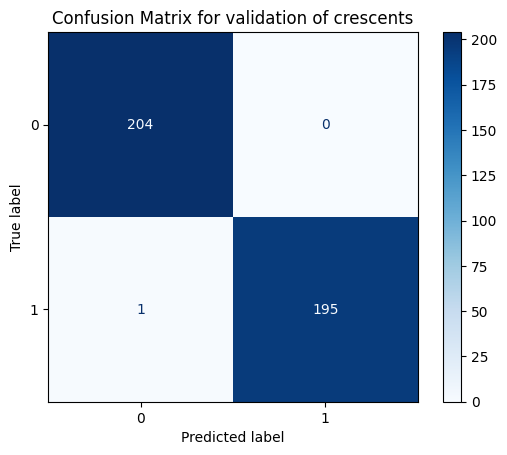

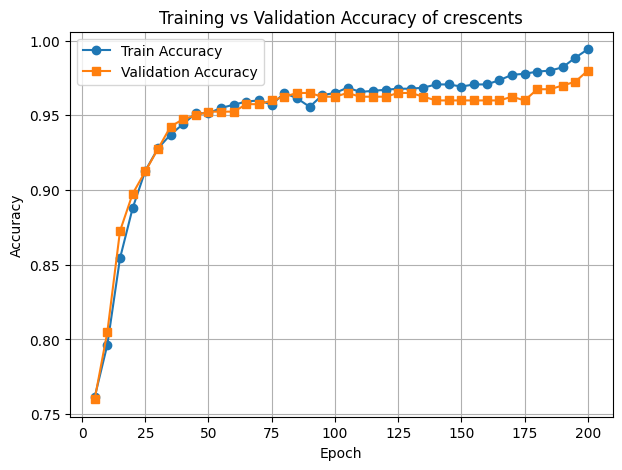

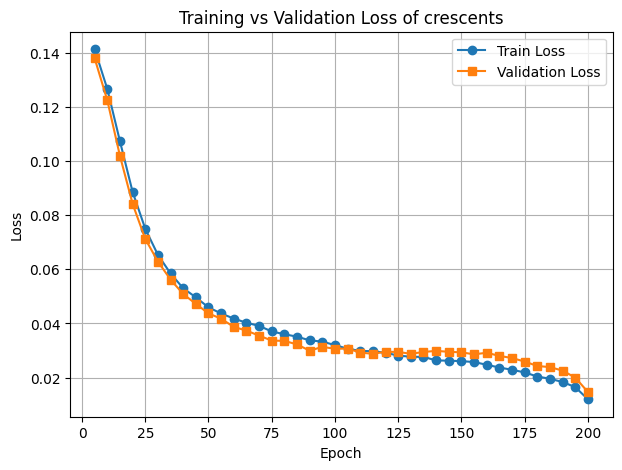

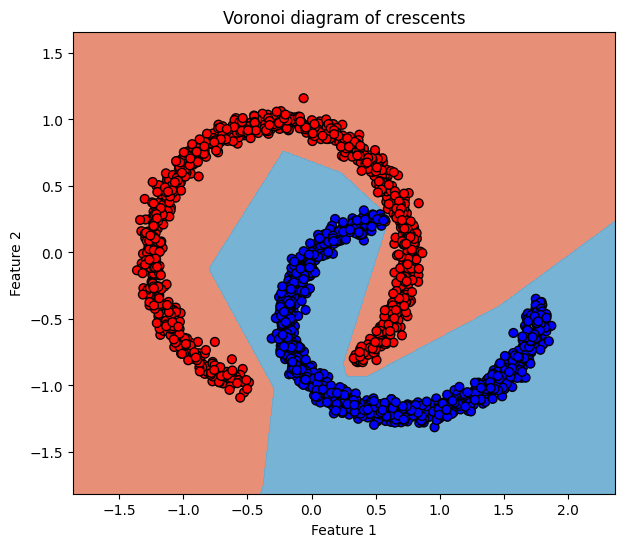

100%|██████████| 200/200 [00:08<00:00, 23.65it/s]

Train accuracy has the distribution: ~N(0.5930000000000001, 0.0016706938775510182)
Validation accuracy has the distribution: ~N(0.558, 0.0014935000000000005)
Test accuracy has the distribution: ~N(0.588, 0.0006859999999999993)
spirals dataset perceptron best results ==>
	Train Accuracy: 0.6307142857142857
	Validation Accuracy: 0.5925
	Test Accuracy: 0.585


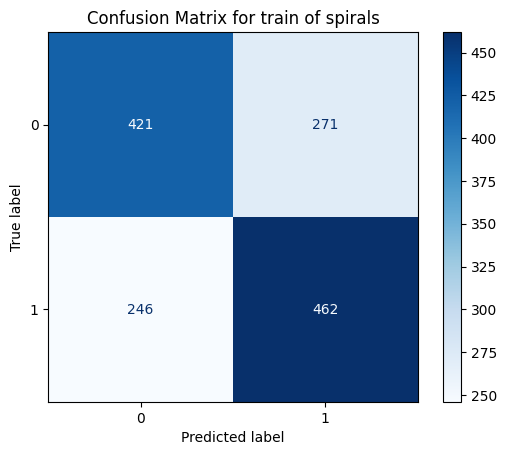

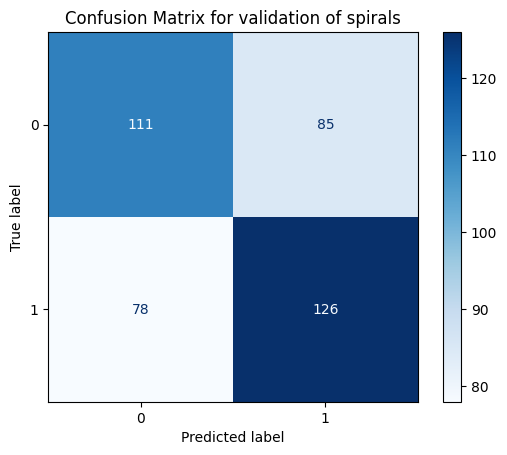

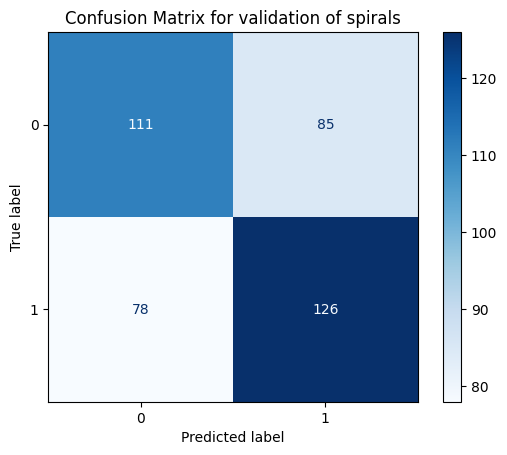

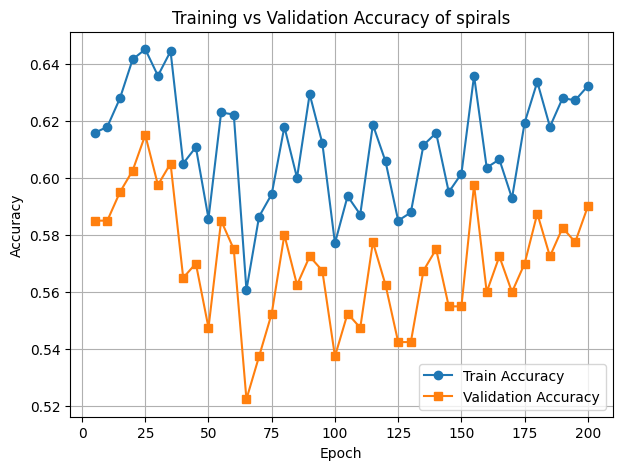

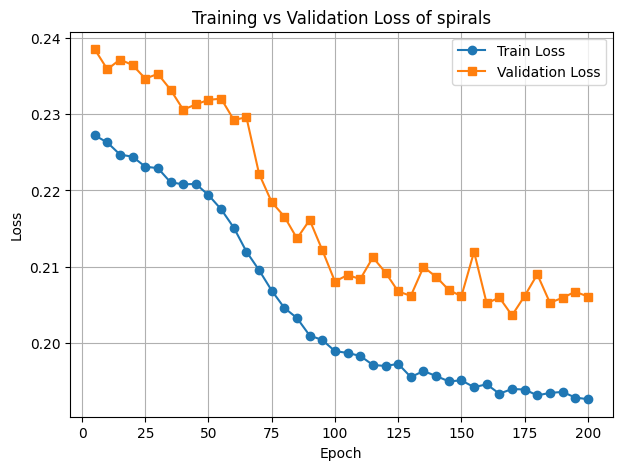

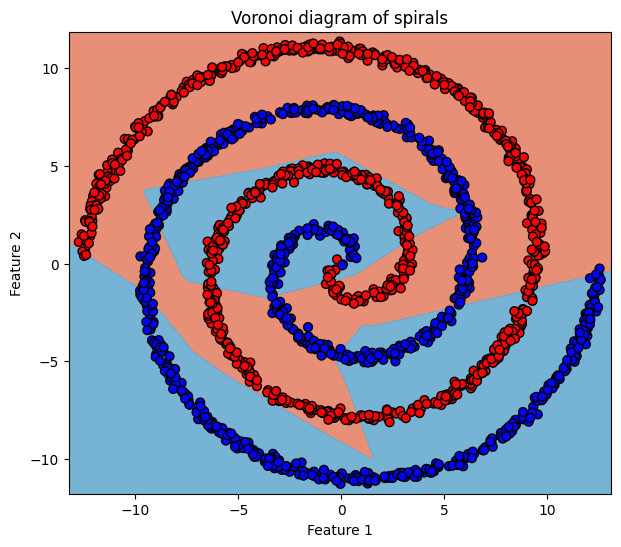

In [25]:
for dset in p_data:
    train_loader = DataLoader(TensorDataset(p_data[dset].X_train, p_data[dset].y_train.float()), batch_size=16, shuffle=True)
    validation_loader = DataLoader(TensorDataset(p_data[dset].X_val, p_data[dset].y_val.float()), batch_size=16)
    test_loader = DataLoader(TensorDataset(p_data[dset].X_test, p_data[dset].y_test.float()), batch_size=16)
    train_acc = []
    val_acc = []
    test_acc = []
    best_model = {
        'train': {
            'acc': [],
            'loss': []
        },
        'val': {
            'acc': [],
            'loss': []
        },
        'model': None
    }
    num_epochs = 200
    lr = 0.002
    for i in range(5):
        train_accuracy = []
        train_loss = []
        val_accuracy = []
        val_loss = []
        model = SingleHiddenNN(2, nn.MSELoss(), 10, lr, 40 + i)
        for epoch in tqdm(range(num_epochs)):
            t_loss, v_loss = model.train_one_epoch(train_loader, validation_loader)
            if (epoch + 1) % 5 == 0:
                train_accuracy.append(model.get_accuracy(p_data[dset].X_train, p_data[dset].y_train))
                val_accuracy.append(model.get_accuracy(p_data[dset].X_val, p_data[dset].y_val))
                train_loss.append(t_loss)
                val_loss.append(v_loss)
    
        train_acc.append(model.get_accuracy(p_data[dset].X_train, p_data[dset].y_train))
        val_acc.append(model.get_accuracy(p_data[dset].X_val, p_data[dset].y_val))
        test_acc.append(model.get_accuracy(p_data[dset].X_test, p_data[dset].y_test))
        if not best_model['val']['acc'] or val_acc[-1] > best_model['val']['acc'][-1]:
            best_model['train']['acc'] = train_accuracy
            best_model['train']['loss'] = train_loss
            best_model['val']['acc'] = val_accuracy
            best_model['val']['loss'] = val_loss
            best_model['model'] = model
    X = torch.cat([p_data[dset].X_train,p_data[dset].X_val,p_data[dset].X_test])
    y = torch.cat([p_data[dset].y_train,p_data[dset].y_val,p_data[dset].y_test])

    train_acc = np.array(train_acc)
    print(f'Train accuracy has the distribution: ~N({np.mean(train_acc)}, {np.var(train_acc)})')
    val_acc = np.array(val_acc)
    print(f'Validation accuracy has the distribution: ~N({np.mean(val_acc)}, {np.var(val_acc)})')
    test_acc = np.array(test_acc)
    print(f'Test accuracy has the distribution: ~N({np.mean(test_acc)}, {np.var(test_acc)})')

    print(f'{dset} dataset perceptron best results ==>')
    print('\tTrain Accuracy:', best_model['train']['acc'][-1])
    print('\tValidation Accuracy:', best_model['val']['acc'][-1])
    print('\tTest Accuracy:', best_model['model'].get_accuracy(p_data[dset].X_test, p_data[dset].y_test))

    plot_confusion_matrix(best_model['model'], train_loader, 'train', dset)
    plot_confusion_matrix(best_model['model'], validation_loader, 'validation', dset)
    plot_confusion_matrix(best_model['model'], validation_loader, 'validation', dset)
    plot_accuracy_map(num_epochs, train_accuracy, val_accuracy, dset)
    plot_loss_map(num_epochs, train_loss, val_loss, dset)
    plot_decision_boundary(best_model['model'], X, y, dset)

### Part C

#### 🌓 Crescent data analysis

The following table illustrates how much was the accuracy gained by testing different models on crescent dataset:

| Learning Rate | Hidden Layer Size | Train Accuracy (Mean, Variance)                     | Validation Accuracy (Mean, Variance)                  | Test Accuracy (Mean, Variance)                       |
|---------------|--------------------|------------------------------------------------------|--------------------------------------------------------|------------------------------------------------------|
| 0.01          | 5                  | 0.9941428571428572, 0.00013722448979591802          | 0.99, 0.0002650000000000002                           | 0.9890000000000001, 0.00030400000000000056          |
| 0.01          | 10                 | 0.9998571428571429, 8.163265306121375e-08           | 0.998, 9.999999999999576e-07                          | 1.0, 0.0                                             |
| 0.01          | 20                 | 1.0, 0.0                                             | 0.9975000000000002, 1.232595164407831e-32              | 1.0, 0.0                                             |
| 0.001         | 5                  | 0.9208571428571428, 0.0031731428571428605           | 0.9254999999999999, 0.002558500000000002              | 0.932, 0.0017359999999999986                       |
| 0.001         | 10                 | 0.9762857142857143, 0.0020851836734693875           | 0.9785, 0.0014440000000000021                         | 0.982, 0.0009759999999999989                       |
| 0.001         | 20                 | 0.9777142857142858, 0.001986612244897959            | 0.9785, 0.0014440000000000021                         | 0.984, 0.0010239999999999987                       |
| 0.0001        | 5                  | 0.8105714285714285, 0.00058395918367347             | 0.821, 0.0005440000000000008                         | 0.844, 9.400000000000017e-05                       |
| 0.0001        | 10                 | 0.8492857142857142, 0.0006059183673469391           | 0.8540000000000001, 0.0003465000000000013             | 0.868, 0.000496000000000001                        |
| 0.0001        | 20                 | 0.8962857142857142, 0.00025783673469387773          | 0.9019999999999999, 0.0001910000000000007             | 0.905, 6.000000000000012e-05                       |

As we can observe the higher the number of **perceptrons** in the hidden layer, the higher the **test accuracy** values. This phenomenon can explain that by increasing the number of perceptrons in our model, we enable it to detect more **complex structures**, and it will increase our model learning capacity. Meanwhile, as is self-explanatory decrease in the **learning rate** caused the model to fail in learning the data in 200 epochs, we conclude this from the fact that the decrease in the learning rate caused a lower **train accuracy** (Train accuracy shows us how well model learns and adapts itself to train data).

> Models training and validating set accuracy and loss change over time


![acc](.\Output\crescent\acc_0.01_5.png)
![loss](.\Output\crescent\loss_0.01_5.png)
![acc](.\Output\crescent\acc_0.001_5.png)
![loss](.\Output\crescent\loss_0.001_5.png)
![acc](.\Output\crescent\acc_0.0001_5.png)
![loss](.\Output\crescent\loss_0.0001_5.png)
![acc](.\Output\crescent\acc_0.01_10.png)
![loss](.\Output\crescent\loss_0.01_10.png)
![acc](.\Output\crescent\acc_0.001_10.png)
![loss](.\Output\crescent\loss_0.001_10.png)
![acc](.\Output\crescent\acc_0.0001_10.png)
![loss](.\Output\crescent\loss_0.0001_10.png)
![acc](.\Output\crescent\acc_0.01_20.png)
![loss](.\Output\crescent\loss_0.01_20.png)
![acc](.\Output\crescent\acc_0.001_20.png)
![loss](.\Output\crescent\loss_0.001_20.png)
![acc](.\Output\crescent\acc_0.0001_20.png)
![loss](.\Output\crescent\loss_0.0001_20.png)



Without a doubt having a single layer with 20 perceptron in the hidden layer with the learning rate of 0.01 is the best option since it's accuracy on the train and test are 100 with a small defection on validation data. This model is also the most stable one since it has almost 0 variance which shows us that this model won't face serious changes and noises against randomness of parameters. This model also shows a very fast adaptation to the data ass can be perceived from the accuracy and loss diagrams.

#### 🌀 Spirals data analysis

The following table illustrates how much was the accuracy gained by testing different models on spirals dataset:

| Learning Rate | Hidden Layer Size | Train Accuracy (Mean, Variance)                   | Validation Accuracy (Mean, Variance)              | Test Accuracy (Mean, Variance)                      |
|---------------|--------------------|---------------------------------------------------|---------------------------------------------------|-----------------------------------------------------|
| 0.01          | 5                  | 0.655, 0.002181632653061225                      | 0.6345, 0.0029159999999999976                    | 0.634, 0.0005040000000000009                       |
| 0.01          | 10                 | 0.8071428571428573, 0.0013342857142857145        | 0.798, 0.0021484999999999976                     | 0.767, 0.003415999999999999                        |
| 0.01          | 20                 | 0.9694285714285714, 0.0007172244897959183        | 0.964, 0.0008514999999999996                     | 0.9739999999999999, 0.0006940000000000013          |
| 0.001         | 5                  | 0.6135714285714287, 0.0013057142857142855        | 0.571, 0.0010815000000000002                     | 0.615, 0.0012800000000000023                       |
| 0.001         | 10                 | 0.5631428571428571, 0.0008391020408163271        | 0.5295, 0.0012335000000000007                    | 0.571, 0.0005439999999999987                       |
| 0.001         | 20                 | 0.5652857142857142, 0.0016401224489795917        | 0.5319999999999999, 0.0021334999999999995        | 0.575, 0.0008499999999999987                       |
| 0.0001        | 5                  | 0.6244285714285714, 0.00012926530612244889       | 0.5885, 0.00017650000000000014                   | 0.625, 0.00013000000000000023                      |
| 0.0001        | 10                 | 0.6297142857142857, 0.0001203265306122442        | 0.598, 0.00017099999999999982                    | 0.631, 0.00042400000000000077                      |
| 0.0001        | 20                 | 0.6437142857142857, 0.00027293877551020376       | 0.606, 0.00012650000000000017                    | 0.645, 0.0004800000000000008                       |

Although we can have the same discussion and outcomes from this table as we had before I want to mention two things: 1. In lower learning rates and epoch numbers, hidden layer size have almost no effect on the outcome of the model and thats because model don't have the chance to learn at all. 2. We can also notice that when the hidden layer size is 20 when the learning rate is increase we have a decreasing and increasing sequence of accuracy. Why that happened? My best guess is that having a large learning rate helped the model to overcome local minimums. 
As foresaid we can also  get the result that learning rate and faster training come together, and the more perceptrons in the hidden layer the more complex model becomes.

> Models training and validating set accuracy and loss change over time


![acc](.\Output\spirals\acc_0.01_5.png)
![loss](.\Output\spirals\loss_0.01_5.png)
![acc](.\Output\spirals\acc_0.001_5.png)
![loss](.\Output\spirals\loss_0.001_5.png)
![acc](.\Output\spirals\acc_0.0001_5.png)
![loss](.\Output\spirals\loss_0.0001_5.png)
![acc](.\Output\spirals\acc_0.01_10.png)
![loss](.\Output\spirals\loss_0.01_10.png)
![acc](.\Output\spirals\acc_0.001_10.png)
![loss](.\Output\spirals\loss_0.001_10.png)
![acc](.\Output\spirals\acc_0.0001_10.png)
![loss](.\Output\spirals\loss_0.0001_10.png)
![acc](.\Output\spirals\acc_0.01_20.png)
![loss](.\Output\spirals\loss_0.01_20.png)
![acc](.\Output\spirals\acc_0.001_20.png)
![loss](.\Output\spirals\loss_0.001_20.png)
![acc](.\Output\spirals\acc_0.0001_20.png)
![loss](.\Output\spirals\loss_0.0001_20.png)



Without a doubt having a single layer with 20 perceptron in the hidden layer with the learning rate of 0.01 is the best option since it's accuracy on the train and test are the only result that is higher than 80%. Meanwhile by looking at the chart we can figure out that 0.01 is the best learning rate, because in every chart that has a lower lr we can perceive that evaluation points of train and validation have a considerable margin from each other. Also 5 and 10 perceptrons in hidden layer tend to be more noisy on the chart (It means that these models are less stable) which shows us that 20 and 0.01 is the best combination.

In [26]:
for dset in p_data:
    train_loader = DataLoader(TensorDataset(p_data[dset].X_train, p_data[dset].y_train.float()), batch_size=16, shuffle=True)
    validation_loader = DataLoader(TensorDataset(p_data[dset].X_val, p_data[dset].y_val.float()), batch_size=16)
    test_loader = DataLoader(TensorDataset(p_data[dset].X_test, p_data[dset].y_test.float()), batch_size=16)
    models_data = []
    num_epochs = 200

    for lr, hidden_size in tqdm(product([0.01, 0.001, 0.0001], [5, 10, 20]), total=3*3):
            train_acc = []
            val_acc = []
            test_acc = []
            for i in range(5):
                train_accuracy = []
                train_loss = []
                val_accuracy = []
                val_loss = []
                model = SingleHiddenNN(2, nn.MSELoss(), hidden_size, lr, 40 + i)
                for epoch in range(num_epochs):
                    t_loss, v_loss = model.train_one_epoch(train_loader, validation_loader)
                    if (epoch + 1) % 5 == 0:
                        train_accuracy.append(model.get_accuracy(p_data[dset].X_train, p_data[dset].y_train))
                        val_accuracy.append(model.get_accuracy(p_data[dset].X_val, p_data[dset].y_val))
                        train_loss.append(t_loss)
                        val_loss.append(v_loss)
                train_acc.append(model.get_accuracy(p_data[dset].X_train, p_data[dset].y_train))
                val_acc.append(model.get_accuracy(p_data[dset].X_val, p_data[dset].y_val))
                test_acc.append(model.get_accuracy(p_data[dset].X_test, p_data[dset].y_test))
            
            train_acc = np.array(train_acc)
            val_acc = np.array(val_acc)
            test_acc = np.array(test_acc)
            models_data.append({
                'model': model,
                'learning_rate': lr,
                'hidden_layer_size': hidden_size,
                'train': {
                    'last_acc': train_accuracy,
                    'last_loss': train_loss,
                },
                'validation': {
                    'last_acc': val_accuracy,
                    'last_loss': val_loss
                },
                'evaluation': {
                    'train': (np.mean(train_acc), np.var(train_acc)),
                    'validation': (np.mean(val_acc), np.var(val_acc)),
                    'test': (np.mean(test_acc), np.var(test_acc))
                }
            })
    X = torch.cat([p_data[dset].X_train,p_data[dset].X_val,p_data[dset].X_test])
    y = torch.cat([p_data[dset].y_train,p_data[dset].y_val,p_data[dset].y_test])
    for md in models_data:
        print(f"Single hidden layer network with learning rate of {md['learning_rate']} and {md['hidden_layer_size']} perceptron in hidden layer.")
        print(f"\tTrain accuracy has the distribution: ~N({md['evaluation']['train'][0]}, {md['evaluation']['train'][1]})")
        print(f"\tValidation accuracy has the distribution: ~N({md['evaluation']['validation'][0]}, {md['evaluation']['validation'][1]})")
        print(f"\tTest accuracy has the distribution: ~N({md['evaluation']['test'][0]}, {md['evaluation']['test'][1]})")
        plot_accuracy_map(num_epochs, md['train']['last_acc'], md['validation']['last_acc'], str(dset + f"[{md['learning_rate']} - {md['hidden_layer_size']}]"))
        plot_loss_map(num_epochs, md['train']['last_loss'], md['validation']['last_loss'], str(dset + f"[{md['learning_rate']} - {md['hidden_layer_size']}]"))
        print('#' * 100)
    print('|' * 100)

  0%|          | 0/9 [00:08<?, ?it/s]


KeyboardInterrupt: 

### Part D

#### MLP to Classify Spirals dataset
**Why this architecture makes sense?**

1. Each Linear + LeakyReLU block performs a piecewise-linear mapping.
Each neuron before activation defines a half-space — in other words, it computes Wx+b and becomes active when this value is positive (LeakyReLU keeps a small slope on the negative side).
So the first layer with 8 neurons creates eight half-spaces in the 2D input space, forming linear boundaries. These are the building blocks of the decision regions.

2. Deeper layers make the boundaries more complex.
The second layer (also with 8 neurons) takes the convex regions from the first layer, combines them linearly, and re-applies LeakyReLU. Geometrically, this folds and twists the convex regions, producing curved, concave, and disconnected shapes. In general, the number of linear regions the network can represent grows exponentially with depth — meaning that even two hidden layers with eight neurons each can approximate the multi-turn spiral boundary quite well.

3. The third hidden layer (4 neurons) compresses the representation, forming a lower-dimensional but still highly nonlinear feature space before the output. The final neuron (linear + sigmoid) combines everything into a single scalar between 0 and 1 — that sigmoid threshold defines the final nonlinear decision boundary.

**Architecture & Parameters**

| Layer (type)   | Output Shape | Param # |
|----------------|---------------|----------|
| 1-Linear       | [-1, 8]       | 24       |
| 2-LeakyReLU    | [-1, 8]       | 0        |
| 3-Linear       | [-1, 8]       | 72       |
| 4-LeakyReLU    | [-1, 8]       | 0        |
| 5-Linear       | [-1, 4]       | 36       |
| 6-LeakyReLU    | [-1, 4]       | 0        |
| 7-Linear       | [-1, 1]       | 5        |
| 8-Sigmoid      | [-1, 1]       | 0        |

Total params: 137  
Trainable params: 137  
Non-trainable params: 0

**Evaluation**<br>
Train accuracy  ~N(0.9975714285714286, 7.469387755102176e-06)<br>
Validation accuracy  ~N(0.9930000000000001, 3.100000000000001e-05)<br>
Test accuracy  ~N(1.0, 0.0)

**Diagrams**<br>
![Accuracy](.\Output\Accuracy.diagram.spirals.mlp.png)
![Loss](.\Output\Loss.diagram.spirals.mlp.png)
![Voronoi Diagram](.\Output\Voronoi.diagram.spirals.mlp.png)



**Comparison Table: Base Model vs. MLP**

| Metric                               |        Base Model (Perceptron)       |                              MLP Model                              |
| :----------------------------------- | :----------------------------------: | :-----------------------------------------------------------------: |
| **Architecture**                     |        Single-layer Perceptron       | 3 hidden layers (8 → 8 → 4 neurons) with LeakyReLU + Sigmoid output |
| **Train Accuracy (mean ± var)**      |         ~N(0.6116, 8.98×10⁻⁷)        |                        ~N(0.9976, 7.47×10⁻⁶)                        |
| **Validation Accuracy (mean ± var)** |         ~N(0.5745, 8.50×10⁻⁶)        |                        ~N(0.9930, 3.10×10⁻⁵)                        |
| **Test Accuracy (mean ± var)**       |            ~N(0.6050, 0.0)           |                           ~N(1.0000, 0.0)                           |
| **Overall Performance**              | Moderate learning and generalization |          Excellent learning, almost perfect generalization          |


**Analysis: Why the MLP Performs Better**

The **perceptron** is a *linear model* that can only separate data using a single straight hyperplane. Therefore, it struggles with **non-linearly separable datasets**, such as the *spiral* dataset, which requires curved or twisted decision boundaries.

The **MLP**, on the other hand, introduces **depth and nonlinearity** through multiple hidden layers and LeakyReLU activations. Each layer transforms the input space by folding and combining linear regions from previous layers. This process allows the network to approximate **highly non-convex and nonlinear decision boundaries**, perfectly fitting the spiral pattern.

In simpler terms:

* The perceptron creates only one straight boundary → cannot capture the spiral’s twists.
* The MLP builds a hierarchy of nonlinear transformations → can “bend” the space and wrap around spiral arms.

As a result, the MLP achieves near-perfect accuracy across all splits (train, validation, test), showing its strong capacity to learn complex mappings and generalize effectively.





100%|██████████| 200/200 [00:17<00:00, 11.39it/s]

Train accuracy has the distribution: ~N(0.9975714285714286, 7.469387755102176e-06)
Validation accuracy has the distribution: ~N(0.9930000000000001, 3.100000000000001e-05)
Test accuracy has the distribution: ~N(1.0, 0.0)
spirals dataset perceptron best results ==>
	Train Accuracy: 0.9985714285714286
	Validation Accuracy: 0.9975
	Test Accuracy: 1.0
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 8]              24
         LeakyReLU-2                    [-1, 8]               0
            Linear-3                    [-1, 8]              72
         LeakyReLU-4                    [-1, 8]               0
            Linear-5                    [-1, 4]              36
         LeakyReLU-6                    [-1, 4]               0
            Linear-7                    [-1, 1]               5
           Sigmoid-8                    [-1, 1]               0
Total para

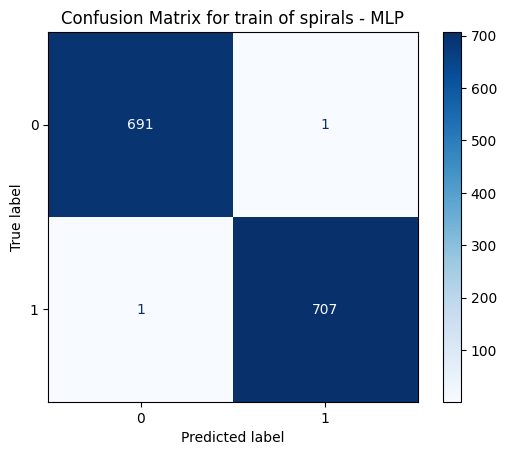

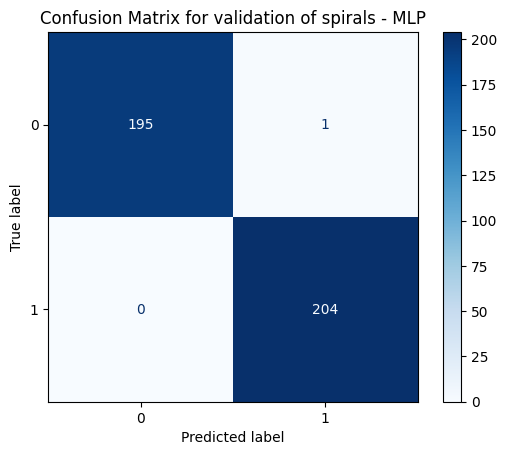

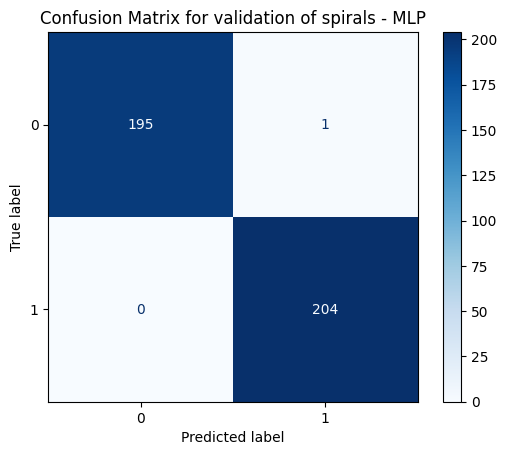

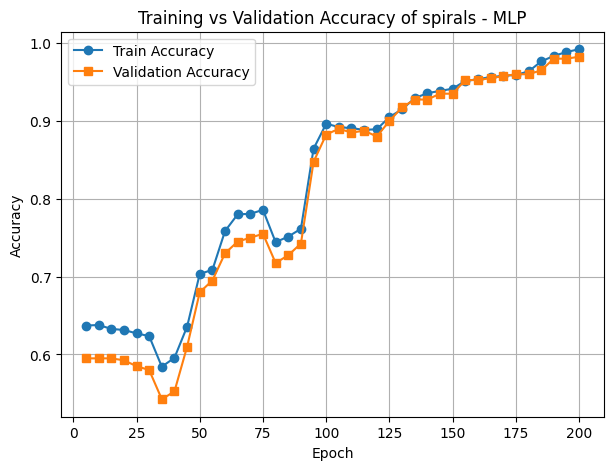

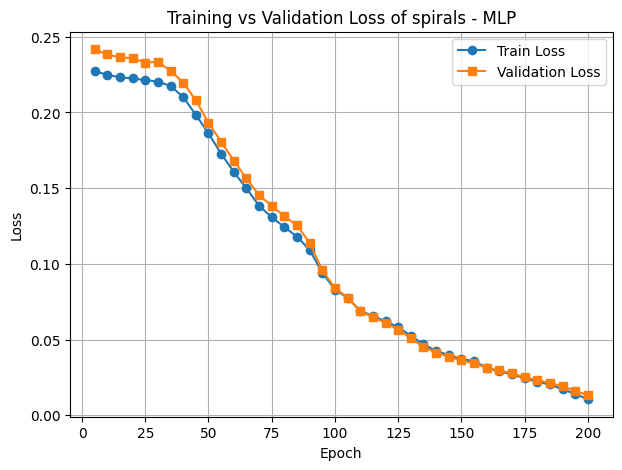

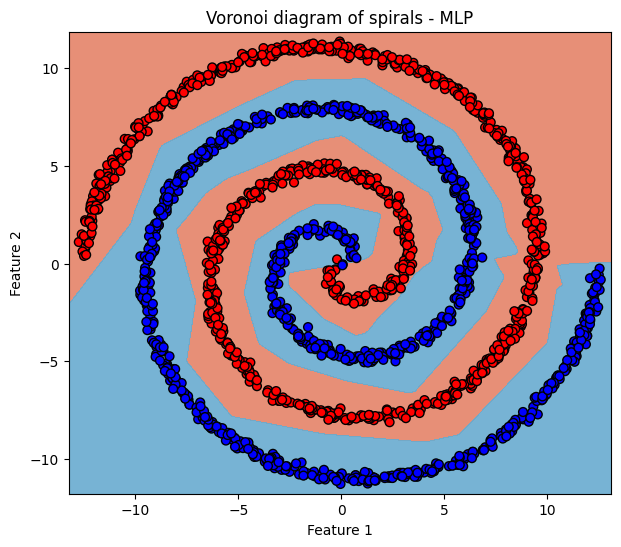

In [30]:
dset = 'spirals'
train_loader = DataLoader(TensorDataset(p_data[dset].X_train, p_data[dset].y_train.float()), batch_size=16, shuffle=True)
validation_loader = DataLoader(TensorDataset(p_data[dset].X_val, p_data[dset].y_val.float()), batch_size=16)
test_loader = DataLoader(TensorDataset(p_data[dset].X_test, p_data[dset].y_test.float()), batch_size=16)
train_acc = []
val_acc = []
test_acc = []
best_model = {
    'train': {
        'acc': [],
        'loss': []
    },
    'val': {
        'acc': [],
        'loss': []
    },
    'model': None
}
num_epochs = 200
lr = 0.001
for i in range(5):
    train_accuracy = []
    train_loss = []
    val_accuracy = []
    val_loss = []
    model = MLP(2, nn.MSELoss(), lr, 40 + i )
    for epoch in tqdm(range(num_epochs)):
        t_loss, v_loss = model.train_one_epoch(train_loader, validation_loader)
        if (epoch + 1) % 5 == 0:
            train_accuracy.append(model.get_accuracy(p_data[dset].X_train, p_data[dset].y_train))
            val_accuracy.append(model.get_accuracy(p_data[dset].X_val, p_data[dset].y_val))
            train_loss.append(t_loss)
            val_loss.append(v_loss)
    train_acc.append(model.get_accuracy(p_data[dset].X_train, p_data[dset].y_train))
    val_acc.append(model.get_accuracy(p_data[dset].X_val, p_data[dset].y_val))
    test_acc.append(model.get_accuracy(p_data[dset].X_test, p_data[dset].y_test))
    if not best_model['val']['acc'] or val_acc[-1] > best_model['val']['acc'][-1]:
        best_model['train']['acc'] = train_accuracy
        best_model['train']['loss'] = train_loss
        best_model['val']['acc'] = val_accuracy
        best_model['val']['loss'] = val_loss
        best_model['model'] = model
X = torch.cat([p_data[dset].X_train,p_data[dset].X_val,p_data[dset].X_test])
y = torch.cat([p_data[dset].y_train,p_data[dset].y_val,p_data[dset].y_test])

train_acc = np.array(train_acc)
print(f'Train accuracy has the distribution: ~N({np.mean(train_acc)}, {np.var(train_acc)})')
val_acc = np.array(val_acc)
print(f'Validation accuracy has the distribution: ~N({np.mean(val_acc)}, {np.var(val_acc)})')
test_acc = np.array(test_acc)
print(f'Test accuracy has the distribution: ~N({np.mean(test_acc)}, {np.var(test_acc)})')

print(f'{dset} dataset perceptron best results ==>')
print('\tTrain Accuracy:', best_model['train']['acc'][-1])
print('\tValidation Accuracy:', best_model['val']['acc'][-1])
print('\tTest Accuracy:', best_model['model'].get_accuracy(p_data[dset].X_test, p_data[dset].y_test))

summary(model, input_size=(2,))
plot_confusion_matrix(best_model['model'], train_loader, 'train', dset + ' - MLP')
plot_confusion_matrix(best_model['model'], validation_loader, 'validation', dset + ' - MLP')
plot_confusion_matrix(best_model['model'], validation_loader, 'validation', dset + ' - MLP')
plot_accuracy_map(num_epochs, train_accuracy, val_accuracy, dset + ' - MLP')
plot_loss_map(num_epochs, train_loss, val_loss, dset + ' - MLP')
plot_decision_boundary(best_model['model'], X, y, dset + ' - MLP')
    

## Final

> **This code was provided by Mohammad-Reza Esmailian**